In [628]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.simp import SimpModelSimp
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [767]:
simp = SimpModelSimp()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + simp.params.duration/simp.params.dt)
test_step = 1e-12

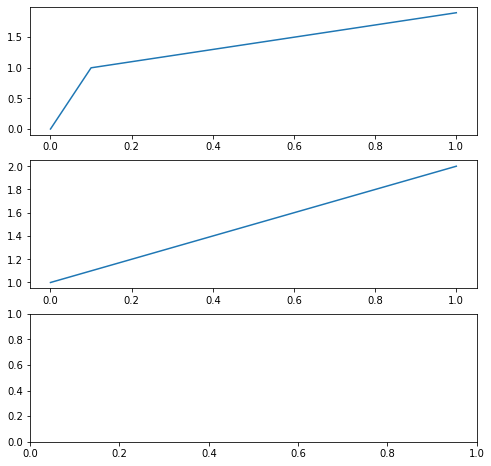

In [824]:
dur = 1.

simp.params.duration = dur
simp.params.ext_exc_current = 0.

target = simp.getZeroTarget()
control1 = simp.getZeroControl()
control0 = simp.getZeroControl()

control1[0,0,:] += 1.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+simp.params.dt,simp.params.dt))
control0[0,0,1:-1] = 0.5

simp.run(control=control1)

target[:,0,:] = simp.rates_exc[:,:]

fig, axes = plt.subplots(3, figsize=(8, 8))
axes[0].plot(simp.t, simp.state["rates_exc"][0,:])
axes[1].plot(simp.t, simp.state["mufe"][0,:])
#axes[2].plot(simp.t, simp.state["tau_exc"][0,:])

In [822]:
max_cntrl = 100. * 5.
start_step = 100.
cost_params = [1.0, 1.0, 0.0]

init_state_vars = np.array( [simp.params.rates_exc_init, simp.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = simp.getZeroControl()
#control2 += 1.

max_it = 80

A1_bestControlA, A1_bestStateA, A1_costA, runtime = simp.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  0.57
RUN  1 , total integrated cost =  0.5217905731307474
RUN  2 , total integrated cost =  0.5217440382429368
RUN  3 , total integrated cost =  0.5217437796140381
RUN  4 , total integrated cost =  0.5217437792899392
RUN  5 , total integrated cost =  0.5217437792887414
RUN  6 , total integrated cost =  0.5217437792887393
RUN  7 , total integrated cost =  0.5217437792887392
 max iteration reached, step size =  5.422503757673972e-22
RUN  8 , total integrated cost =  0.5217437792887392
Control only changes marginally.
Improved over  8  iterations by  8.466003633554521  percent.


[[[0.         0.         0.05839839 0.11671585 0.17495238 0.233108
   0.2911827  0.34917651 0.40708942 0.46492144 0.52267259]]]


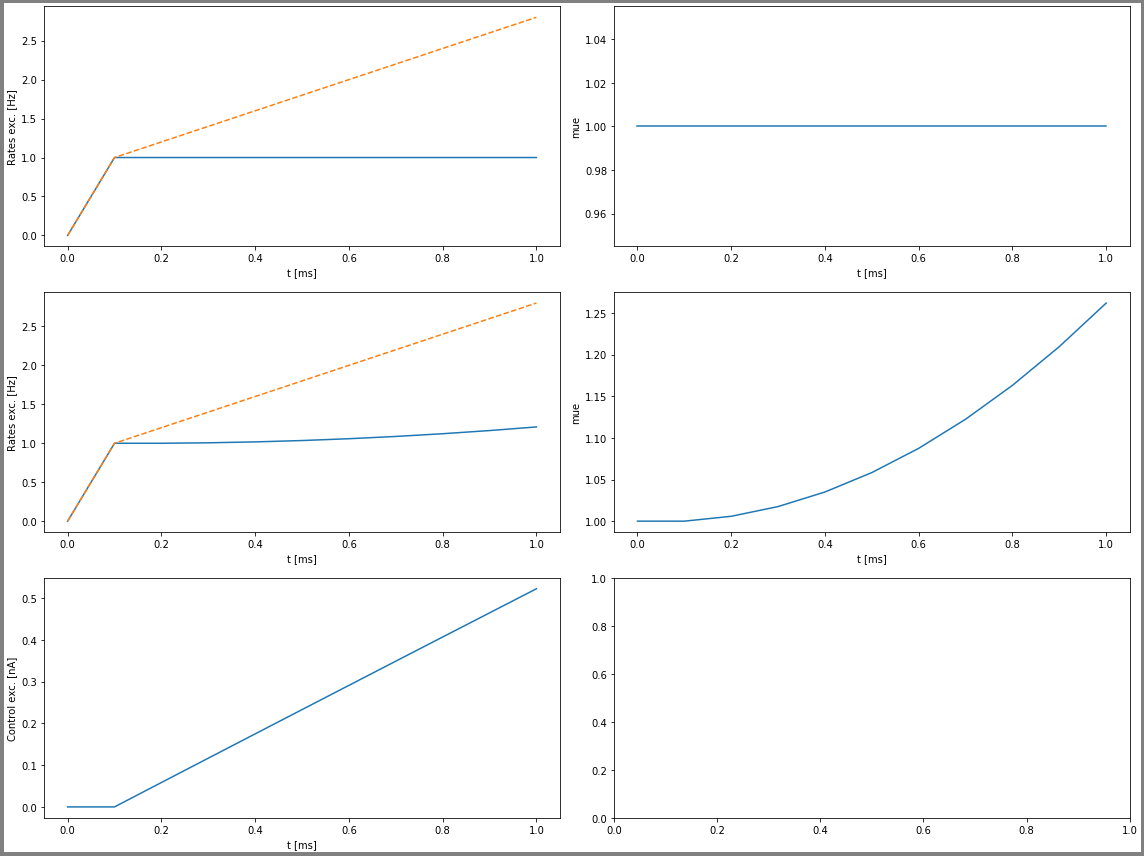

In [823]:
print(A1_bestControlA)
plotFunc.plot_control(simp, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [820]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 45

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = simp.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  0.57
RUN  1 , total integrated cost:  0.42197667950569395
RUN  2 , total integrated cost:  0.41896616777245
change helped, counter =  1
change helped, counter =  1
RUN  3 , total integrated cost:  0.4189441912578476
change helped, counter =  1
change helped, counter =  2
change helped, counter =  4
change helped, counter =  4
change helped, counter =  3
RUN  4 , total integrated cost:  0.4189441481348257
change helped, counter =  3
change helped, counter =  4
change helped, counter =  2
RUN  5 , total integrated cost:  0.41894414792341517
change helped, counter =  3
change helped, counter =  4
change helped, counter =  2
 max iteration reached, step size =  1.6389602509487395e-212
change helped, counter =  4
RUN  6 , total integrated cost:  0.4189441479226206
RUN  7 , total integrated cost:  0.4189441479226194
change helped, counter =  1
change helped, counter =  4
RUN  8 , total integrated cost:  0.4189441479225513
change helped, counter

[[[0.         0.65223384 0.63875607 0.61166693 0.57069254 0.51542644
   0.44531394 0.35965479 0.2575922  0.1381056  0.        ]]]


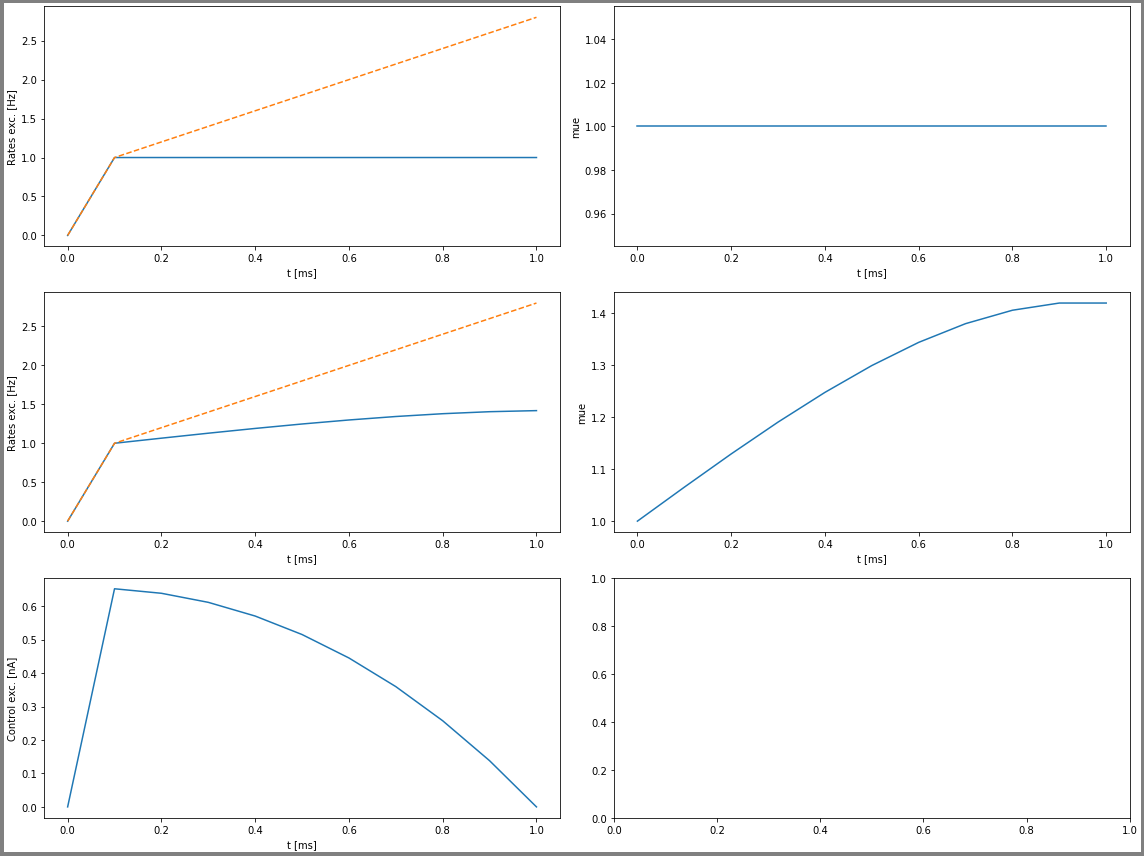

In [821]:
print(A2_bestControlA)
plotFunc.plot_control(simp, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

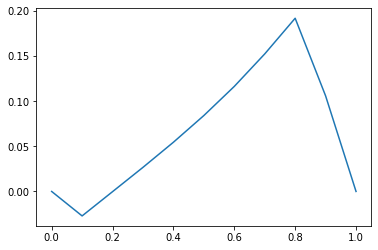

In [809]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(simp.t, diff)
plt.show()

(350, 64, 2)


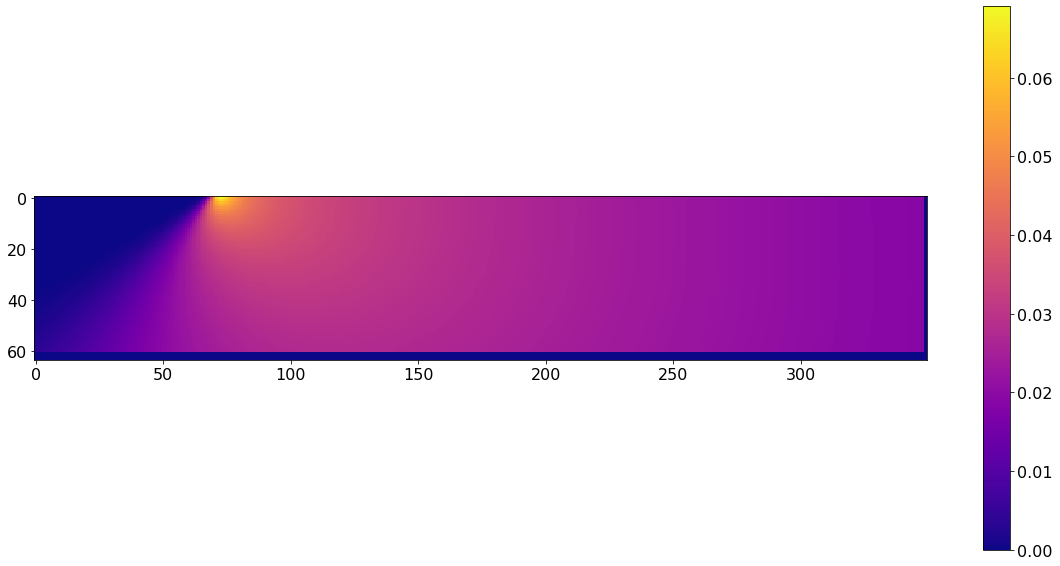

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


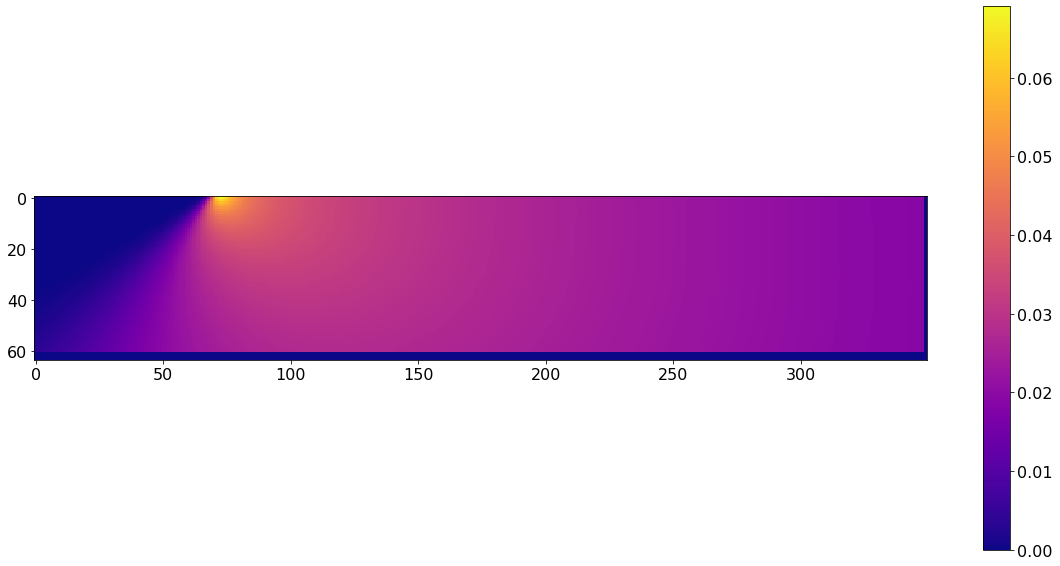

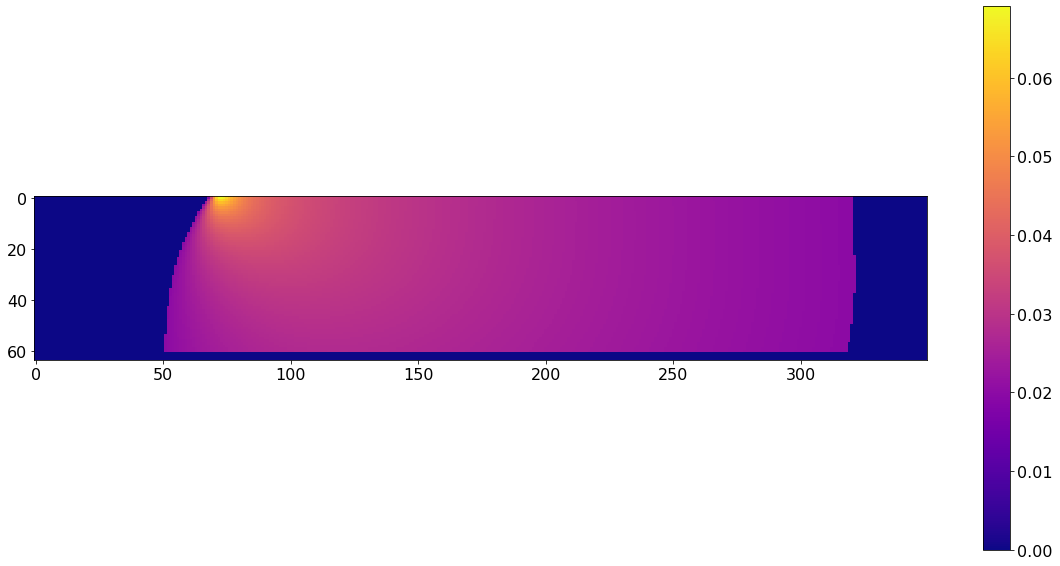

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()